# Mini training (Agulhas)

Short GPU smoke run on top of `configs/agulhas.json`.

After each epoch two figures are shown:

1. **Loss** — train and validation curves.
2. **Fields** — top row: `cos(VMDR − current dir)`, significant wave height `VHM0`, mean period `VTM10`; bottom row: predicted and truth `uo` / `vo` for one fixed validation sample.


In [8]:
import copy
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ocean_velocity.config import load_config
from ocean_velocity.train import (
    _loss,
    _stats,
    evaluate,
    make_dataset,
    make_model,
    seed_everything,
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  [{i}]", torch.cuda.get_device_name(i))

PyTorch: 1.12.1.post201
CUDA available: True
  [0] NVIDIA A100-SXM4-80GB
  [1] NVIDIA A100-SXM4-80GB
  [2] NVIDIA A100-SXM4-80GB
  [3] NVIDIA A100-SXM4-80GB
  [4] NVIDIA A100-SXM4-80GB
  [5] NVIDIA A100-SXM4-80GB
  [6] NVIDIA A100-SXM4-80GB
  [7] NVIDIA A100-SXM4-80GB


In [9]:
# --- knobs ---
GPU_INDEX = 0
EPOCHS = 10
BATCH_SIZE = 4
NUM_WORKERS = 2
MAP_SAMPLE_INDEX = 0  # fixed validation sample for maps

TRAIN_START, TRAIN_END = "20230101", "20230131"
VAL_START, VAL_END = "20230201", "20230207"

OUTPUT_DIR = ROOT / "runs" / "mini_agulhas"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cfg = copy.deepcopy(load_config(ROOT / "configs" / "agulhas.json"))
cfg["data"]["splits"] = {
    "train": {"start": TRAIN_START, "end": TRAIN_END},
    "validation": {"start": VAL_START, "end": VAL_END},
    "test": {"start": VAL_START, "end": VAL_END},
}
device = torch.device(
    f"cuda:{GPU_INDEX}" if torch.cuda.is_available() else "cpu"
)
cfg["training"].update(
    {
        "device": str(device),
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
    }
)

with open(OUTPUT_DIR / "config.json", "w") as handle:
    json.dump(cfg, handle, indent=2)

print("device:", device)
print("epochs:", EPOCHS, "| batch_size:", BATCH_SIZE)
print("train:", TRAIN_START, "→", TRAIN_END)
print("val:  ", VAL_START, "→", VAL_END)
print("target mean/std:", cfg["data"]["normalization"]["target"])
print("output:", OUTPUT_DIR)

device: cuda:0
epochs: 10 | batch_size: 4
train: 20230101 → 20230131
val:   20230201 → 20230207
target mean/std: {'mean': [0.0489, -0.0026], 'std': [0.4311, 0.4583]}
output: /home1/datahome/ilarroch/data/INES/CODE/waves2surfF/waves2surf_net/runs/mini_agulhas


In [10]:
seed_everything(int(cfg["training"].get("seed", 42)))

train_dataset = make_dataset(cfg, "train")
validation_dataset = make_dataset(cfg, "validation")

loader_options = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)

model = make_model(cfg).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg["training"]["learning_rate"],
    weight_decay=cfg["training"].get("weight_decay", 1e-5),
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

input_names = cfg["data"]["input_variables"]
target_names = cfg["data"]["target_variables"]
input_stats = _stats(cfg, "input")
target_stats = _stats(cfg, "target")
viz_sample = validation_dataset[MAP_SAMPLE_INDEX]

bbox = cfg["data"]["bbox"]
MAP_EXTENT = [
    bbox["lon_min"],
    bbox["lon_max"],
    bbox["lat_min"],
    bbox["lat_max"],
]

print(f"train samples: {len(train_dataset)} | val samples: {len(validation_dataset)}")
print(f"inputs: {input_names} | targets: {target_names}")
print(f"map sample index: {MAP_SAMPLE_INDEX} | field shape: {tuple(viz_sample['y'].shape)}")
print(f"lon/lat extent: {MAP_EXTENT}")

train samples: 248 | val samples: 56
inputs: ['VHM0', 'VTM10', 'VMDR'] | targets: ['uo', 'vo']
map sample index: 0 | field shape: (2, 121, 301)
lon/lat extent: [10.0, 35.0, -45.0, -35.0]


In [ ]:
def denormalize(tensor: torch.Tensor, stats) -> torch.Tensor:
    """Undo channel-wise standardization."""
    if stats is None:
        return tensor
    mean = torch.tensor(stats.mean, device=tensor.device, dtype=tensor.dtype)
    std = torch.tensor(stats.std, device=tensor.device, dtype=tensor.dtype)
    while mean.ndim < tensor.ndim:
        mean = mean.unsqueeze(-1)
        std = std.unsqueeze(-1)
    return tensor * std + mean


def masked_field(field: np.ndarray, mask: np.ndarray) -> np.ndarray:
    out = field.astype(np.float64).copy()
    out[mask < 0.5] = np.nan
    return out


def predict_sample(model, sample, device):
    """Return denormalized inputs, prediction, truth, and ocean mask."""
    model.eval()
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(device)
        metadata = sample["metadata"].unsqueeze(0).to(device)
        pred = model(x, metadata)[0].cpu()
        inputs = denormalize(sample["x"].cpu(), input_stats).numpy()
        pred = denormalize(pred, target_stats).numpy()
        truth = denormalize(sample["y"].cpu(), target_stats).numpy()
        mask = sample["valid_mask"][0].cpu().numpy()
    return inputs, pred, truth, mask


def wave_current_cosine(vmdr_deg: np.ndarray, uo: np.ndarray, vo: np.ndarray) -> np.ndarray:
    """Cosine of angle between wave propagation and current velocity.

    Both directions are expressed in the trigonometric framework:
    radians, counterclockwise from east (+x).

    - Current: atan2(vo, uo) with u eastward, v northward.
    - Wave: VMDR is "from" direction in degrees, clockwise from north.
      Convert to geographic "to" (+180°), then to trig: π/2 − θ_geo.
    """
    # Geographic "to" direction (radians, clockwise from north)
    wave_to_geo = np.deg2rad(vmdr_deg) + np.pi
    # Same convention as math polar angle of the (east, north) vector
    wave_trig = np.pi / 2.0 - wave_to_geo
    current_trig = np.arctan2(vo, uo)
    return np.cos(wave_trig - current_trig)


def _imshow(ax, field, title, cmap, vmin=None, vmax=None):
    im = ax.imshow(
        field,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=MAP_EXTENT,
        aspect="equal",  # same scale for lon and lat (degrees)
    )
    ax.set_title(title)
    ax.set_xlabel("longitude (°)")
    ax.set_ylabel("latitude (°)")
    return im


def _colorbar(fig, im, ax, label=None):
    cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
    if label:
        cbar.set_label(label)
    return cbar


def plot_losses(history, epoch):
    epochs = [r["epoch"] for r in history]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(epochs, [r["train_loss"] for r in history], "o-", label="train loss")
    ax.plot(epochs, [r["val_loss"] for r in history], "s-", label="validation loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss (normalized)")
    ax.set_title(f"Loss evolution (epoch {epoch}/{EPOCHS})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def plot_fields(inputs, pred, truth, mask, *, sample_index, epoch=None, title=None):
    """Two-row diagnostic: wave inputs (top) and predicted/truth currents (bottom)."""
    name_to_idx = {name: i for i, name in enumerate(input_names)}
    vhm0 = masked_field(inputs[name_to_idx["VHM0"]], mask)
    vtm10 = masked_field(inputs[name_to_idx["VTM10"]], mask)
    vmdr = inputs[name_to_idx["VMDR"]]
    cos_align = masked_field(wave_current_cosine(vmdr, truth[0], truth[1]), mask)

    fig, axes = plt.subplots(2, 4, figsize=(22, 8))

    panels = [
        (cos_align, r"$\cos$(wave − current) [trig]", "coolwarm", -1.0, 1.0, None),
        (vhm0, "VHM0 (m)", "viridis", None, None, "m"),
        (vtm10, "VTM10 (s)", "plasma", None, None, "s"),
    ]
    for ax, (field, panel_title, cmap, vmin, vmax, cbar_label) in zip(axes[0, :3], panels):
        im = _imshow(ax, field, panel_title, cmap, vmin=vmin, vmax=vmax)
        _colorbar(fig, im, ax, label=cbar_label)
    axes[0, 3].axis("off")
    epoch_txt = f"epoch {epoch}/{EPOCHS}\n" if epoch is not None else ""
    axes[0, 3].text(
        0.0,
        0.5,
        f"sample {sample_index}\n{epoch_txt}\n"
        f"lon [{MAP_EXTENT[0]}, {MAP_EXTENT[1]}]\n"
        f"lat [{MAP_EXTENT[2]}, {MAP_EXTENT[3]}]\n\n"
        "Top: wave inputs\nBottom: surface currents",
        transform=axes[0, 3].transAxes,
        va="center",
        fontsize=11,
    )

    for col, (name, channel) in enumerate(zip(target_names, range(len(target_names)))):
        pred_map = masked_field(pred[channel], mask)
        truth_map = masked_field(truth[channel], mask)
        vmax = max(float(np.nanpercentile(np.abs(truth_map), 98)), 1e-3)
        unit = r"m\,s$^{-1}$"

        im = _imshow(
            axes[1, col * 2],
            pred_map,
            f"pred {name} ({unit})",
            "RdBu_r",
            -vmax,
            vmax,
        )
        _colorbar(fig, im, axes[1, col * 2], label=r"m s$^{-1}$")

        im = _imshow(
            axes[1, col * 2 + 1],
            truth_map,
            f"truth {name} ({unit})",
            "RdBu_r",
            -vmax,
            vmax,
        )
        _colorbar(fig, im, axes[1, col * 2 + 1], label=r"m s$^{-1}$")

    if title is None:
        title = "Wave inputs vs estimated / truth surface currents"
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def plot_validation_examples(model, dataset, device, n_examples=10):
    """Plot wave inputs + pred/truth currents for the first n validation samples."""
    n_examples = min(n_examples, len(dataset))
    print(f"Plotting {n_examples} validation examples…")
    for sample_index in range(n_examples):
        sample = dataset[sample_index]
        inputs, pred, truth, mask = predict_sample(model, sample, device)
        plot_fields(
            inputs,
            pred,
            truth,
            mask,
            sample_index=sample_index,
            title=f"Validation example {sample_index + 1}/{n_examples}",
        )

epoch 1/10 | train_loss=0.6658 | val_loss=0.6452 | lr=9.76e-04


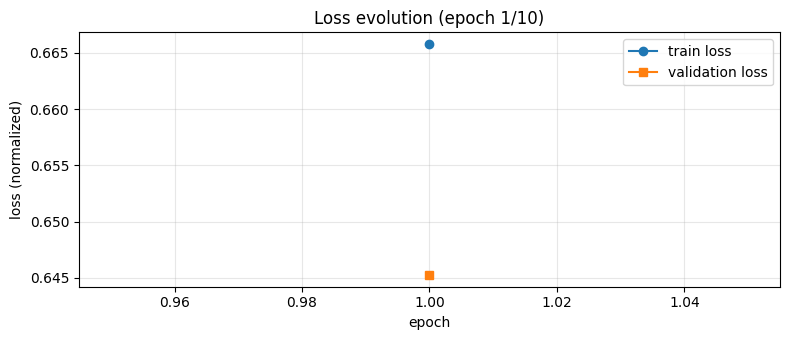

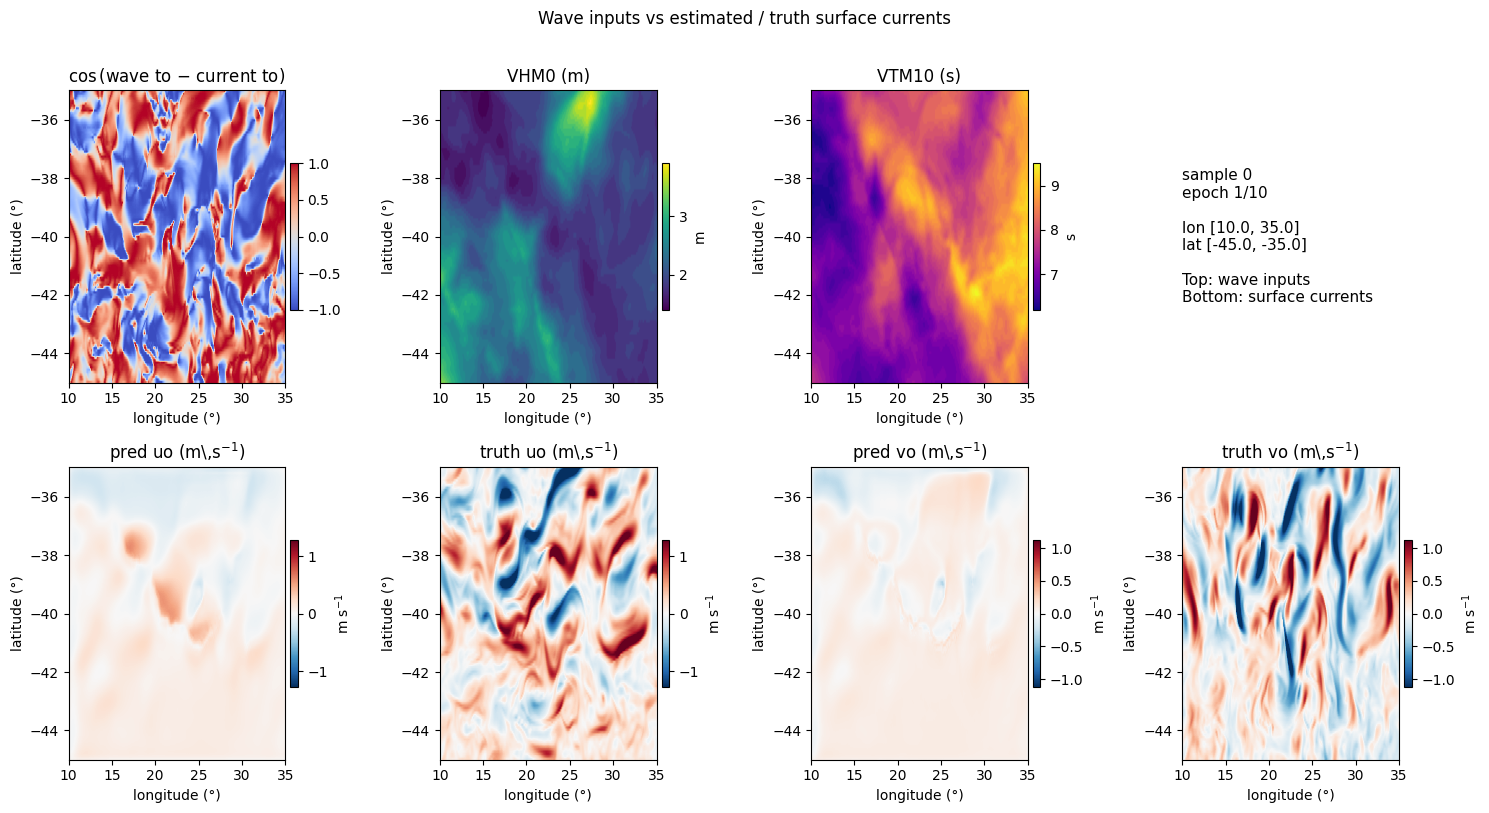

RuntimeError: Caught RuntimeError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/home1/datahome/ilarroch/conda-env/seastatesenv/lib/python3.9/site-packages/torch/utils/data/_utils/worker.py", line 302, in _worker_loop
    data = fetcher.fetch(index)
  File "/home1/datahome/ilarroch/conda-env/seastatesenv/lib/python3.9/site-packages/torch/utils/data/_utils/fetch.py", line 49, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home1/datahome/ilarroch/conda-env/seastatesenv/lib/python3.9/site-packages/torch/utils/data/_utils/fetch.py", line 49, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home1/datahome/ilarroch/data/INES/CODE/waves2surfF/waves2surf_net/ocean_velocity/wavecurrentdataset.py", line 140, in __getitem__
    targets = [
  File "/home1/datahome/ilarroch/data/INES/CODE/waves2surfF/waves2surf_net/ocean_velocity/wavecurrentdataset.py", line 141, in <listcomp>
    self.c

In [12]:
history = []
best_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    n_batches = 0
    for batch in train_loader:
        x = batch["x"].to(device, non_blocking=True)
        y = batch["y"].to(device, non_blocking=True)
        metadata = batch["metadata"].to(device, non_blocking=True)
        mask = batch["valid_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        prediction = model(x, metadata)
        loss, _ = _loss(prediction, y, mask, cfg)
        loss.backward()
        if cfg["training"].get("gradient_clip"):
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), cfg["training"]["gradient_clip"]
            )
        optimizer.step()
        train_loss += loss.item()
        n_batches += 1
    scheduler.step()

    validation = evaluate(model, validation_loader, device, cfg)
    record = {
        "epoch": epoch,
        "train_loss": train_loss / max(n_batches, 1),
        "val_loss": validation["loss"],
        "validation": validation,
        "learning_rate": scheduler.get_last_lr()[0],
    }
    history.append(record)

    if validation["loss"] < best_loss:
        best_loss = validation["loss"]
        torch.save(
            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "best_validation_loss": best_loss,
                "config": cfg,
            },
            OUTPUT_DIR / "best.pt",
        )

    with open(OUTPUT_DIR / "history.json", "w") as handle:
        json.dump(history, handle, indent=2)

    inputs, pred, truth, mask = predict_sample(model, viz_sample, device)
    clear_output(wait=True)
    print(
        f"epoch {epoch}/{EPOCHS} | "
        f"train_loss={record['train_loss']:.4f} | "
        f"val_loss={record['val_loss']:.4f} | "
        f"lr={record['learning_rate']:.2e}"
    )
    plot_losses(history, epoch)
    plot_fields(inputs, pred, truth, mask, sample_index=MAP_SAMPLE_INDEX, epoch=epoch)

torch.save(
    {"model": model.state_dict(), "epoch": EPOCHS, "config": cfg},
    OUTPUT_DIR / "last.pt",
)
print("Done. Checkpoints and history in", OUTPUT_DIR)

## Validation gallery

Plot model outputs for the first `N_VAL_EXAMPLES` samples of the validation set (wave inputs on top, predicted/truth currents below).

Plotting 10 validation examples…


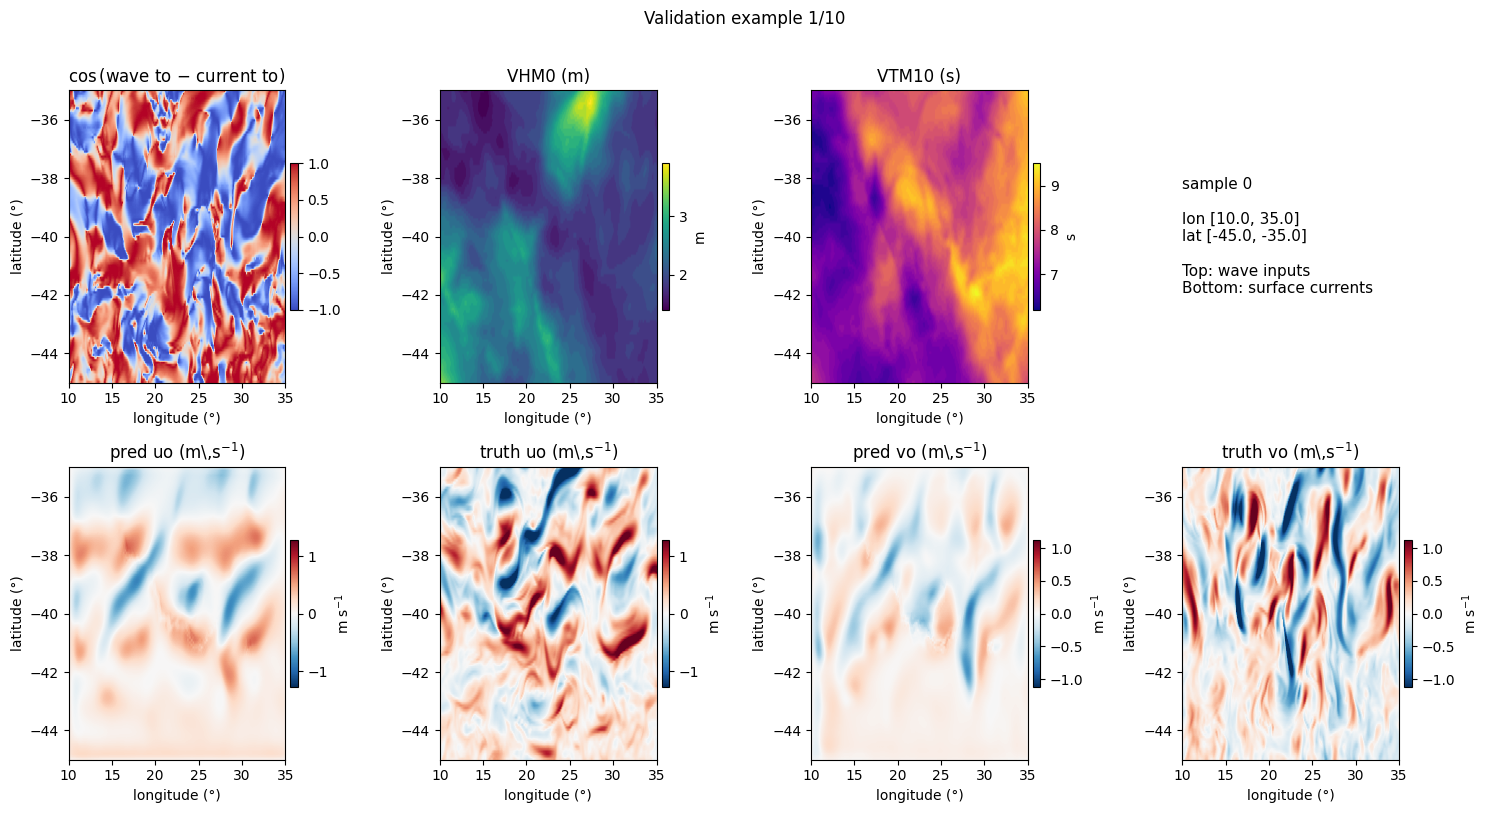

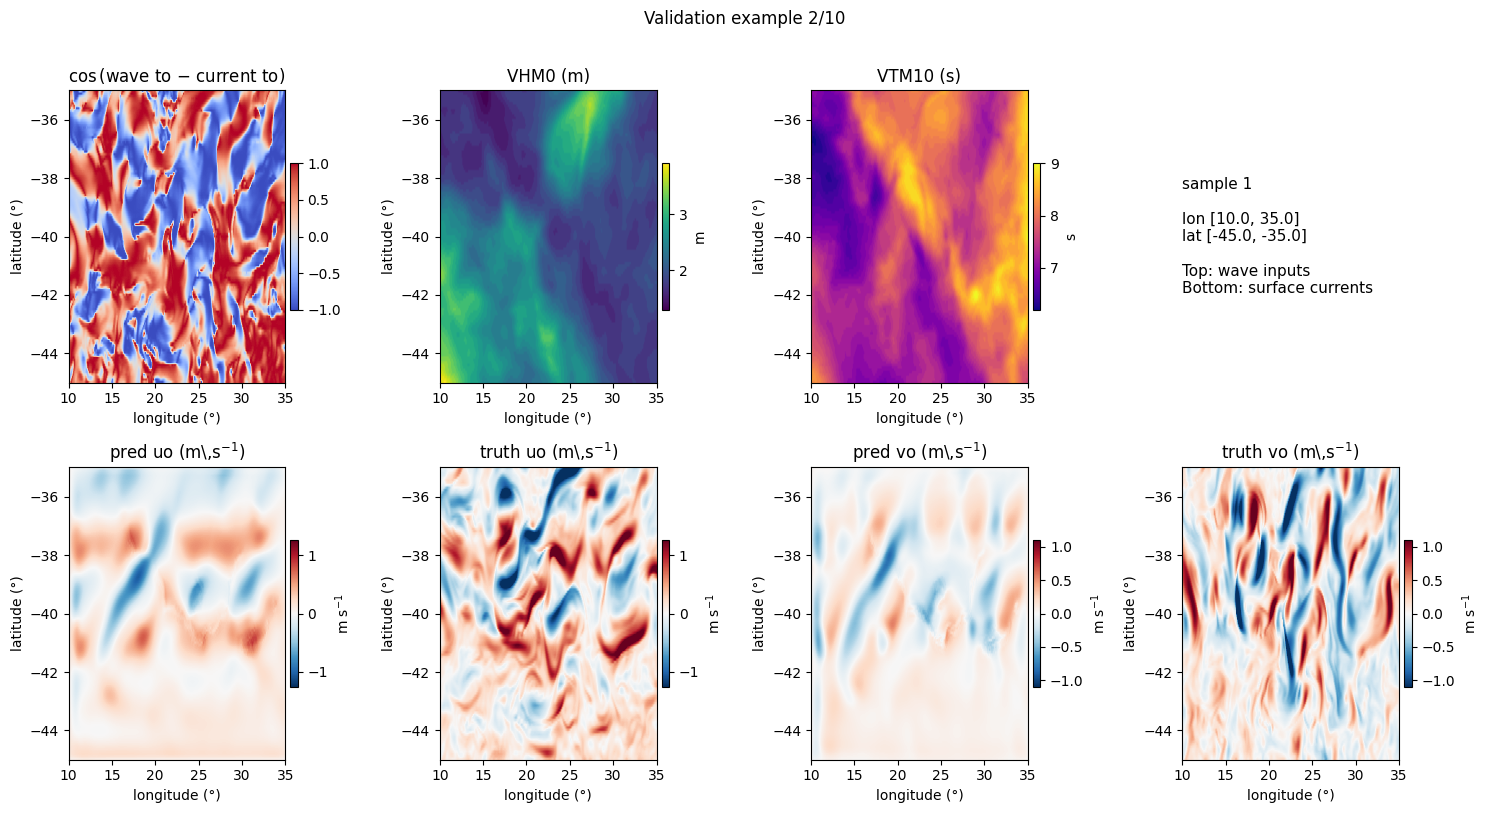

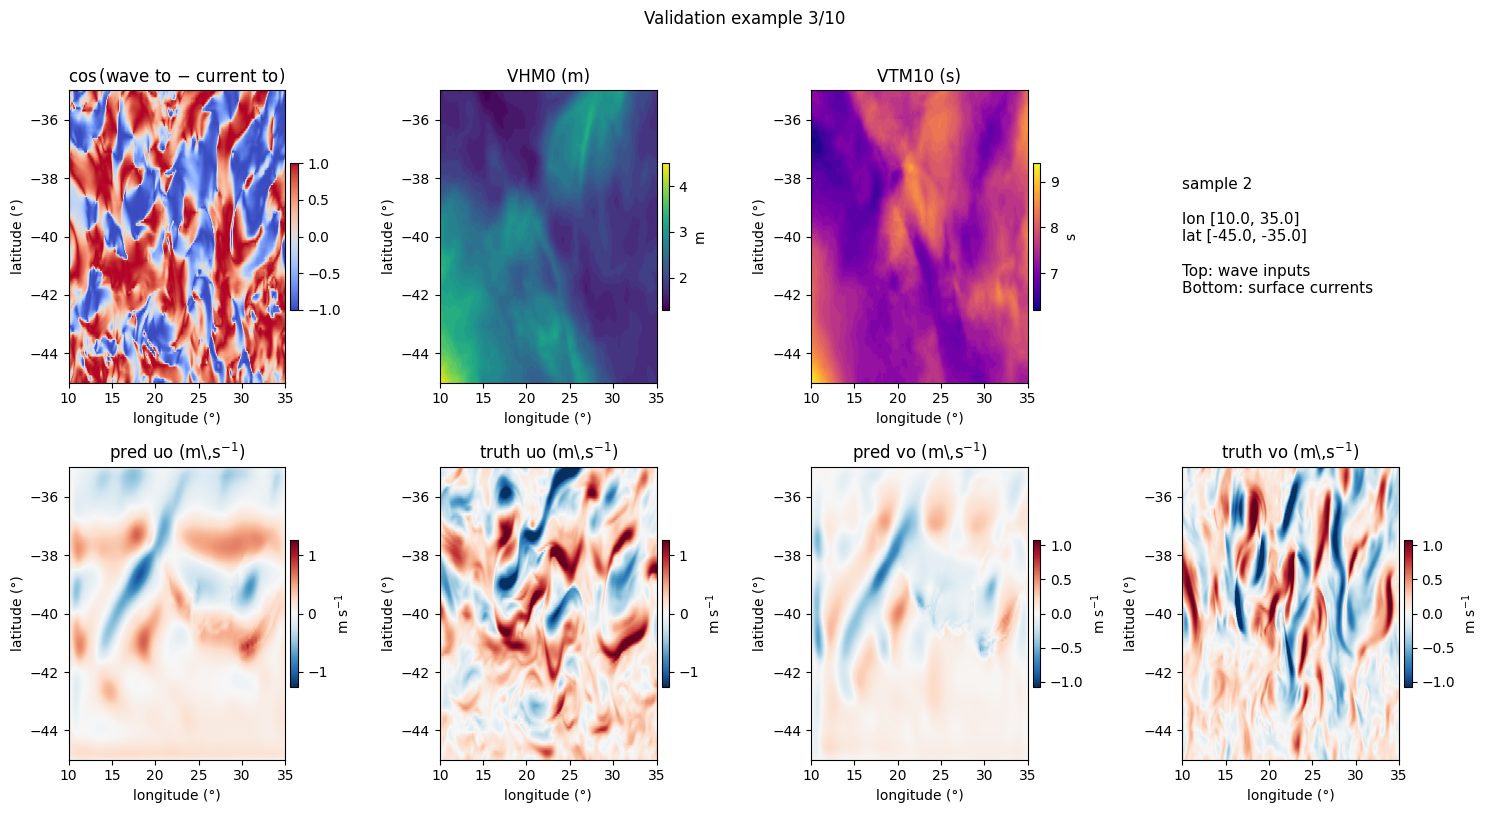

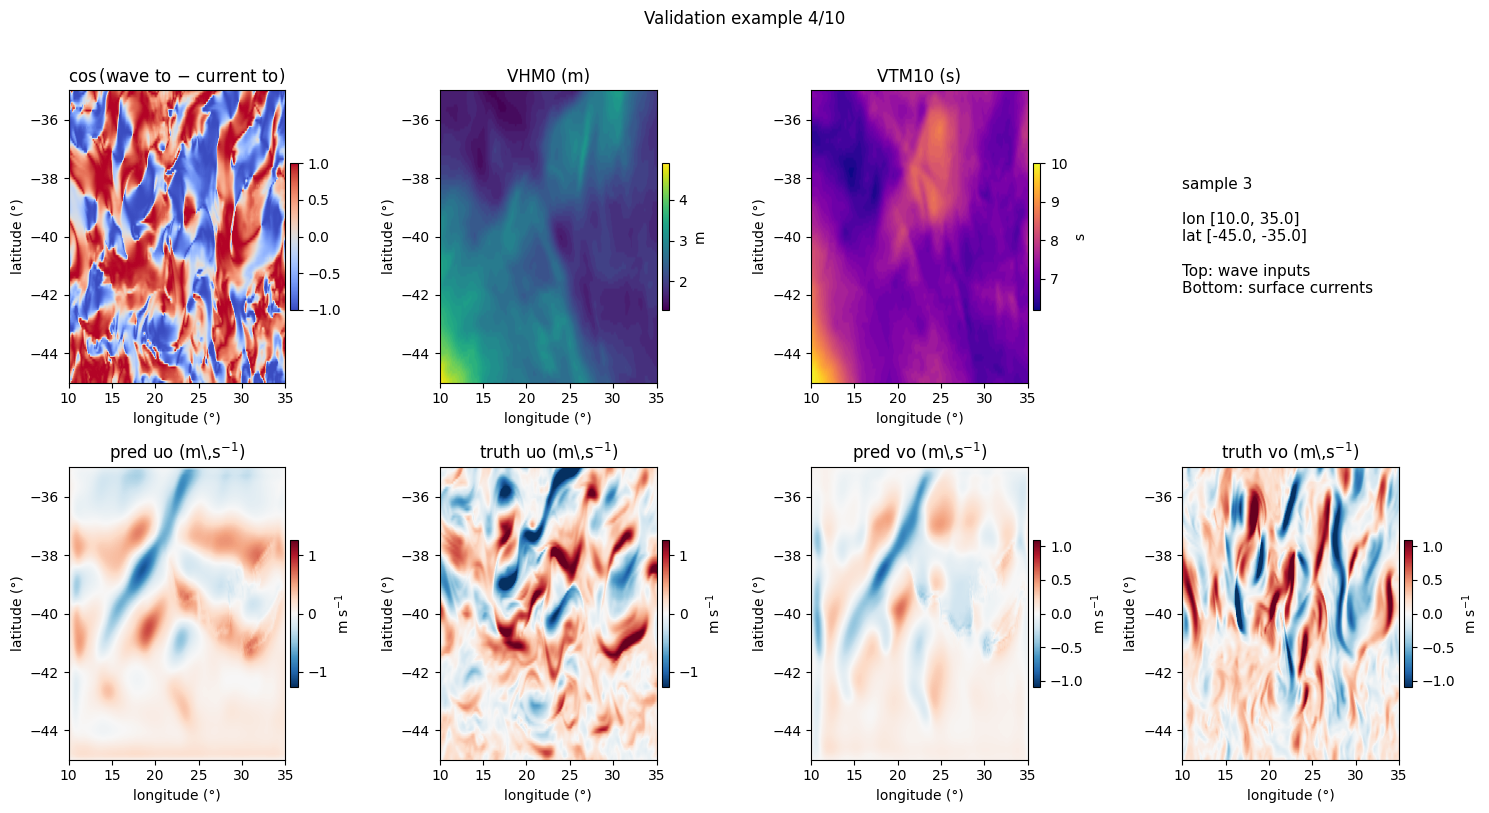

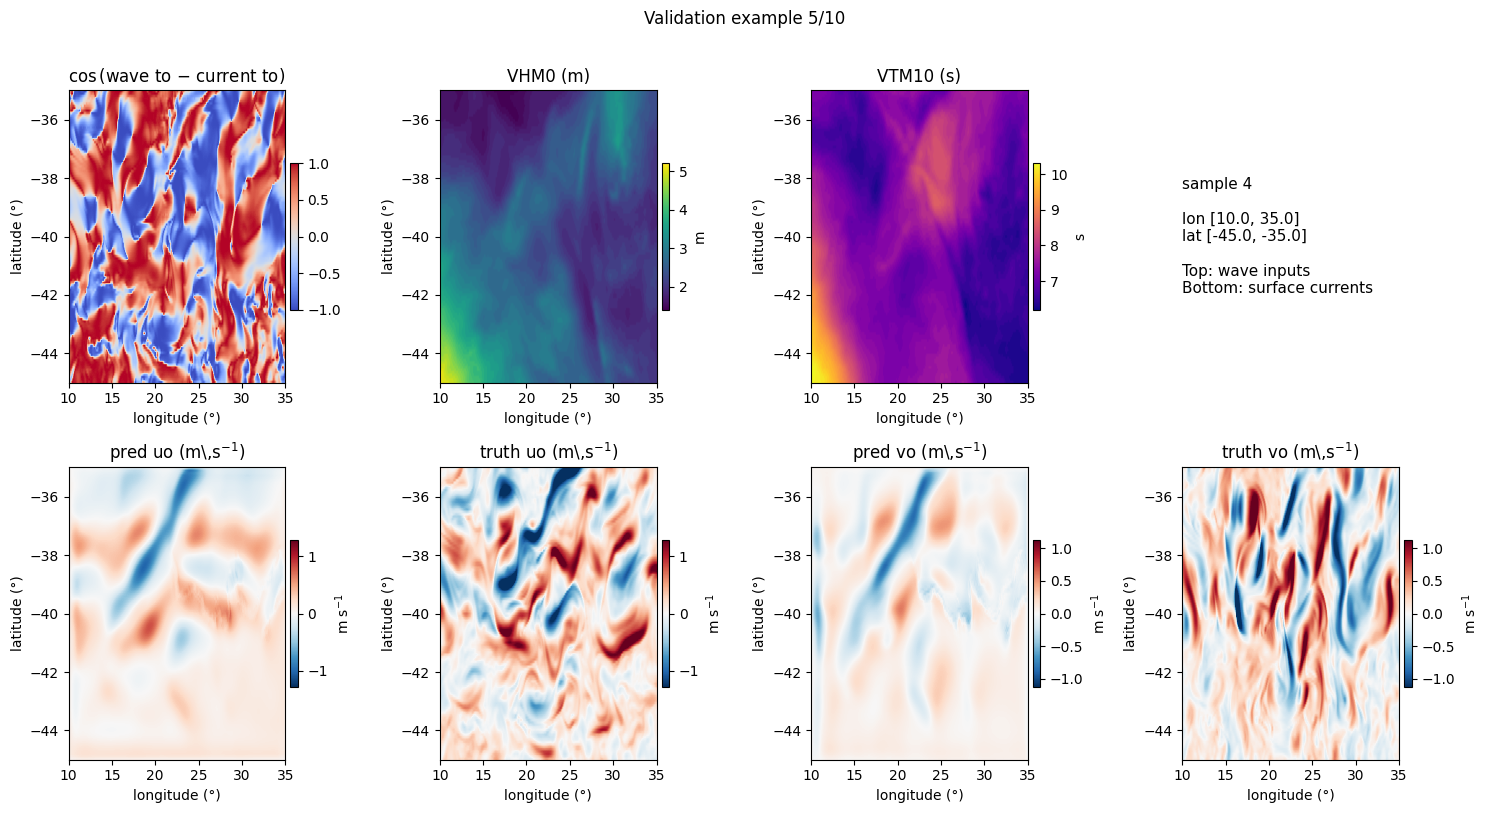

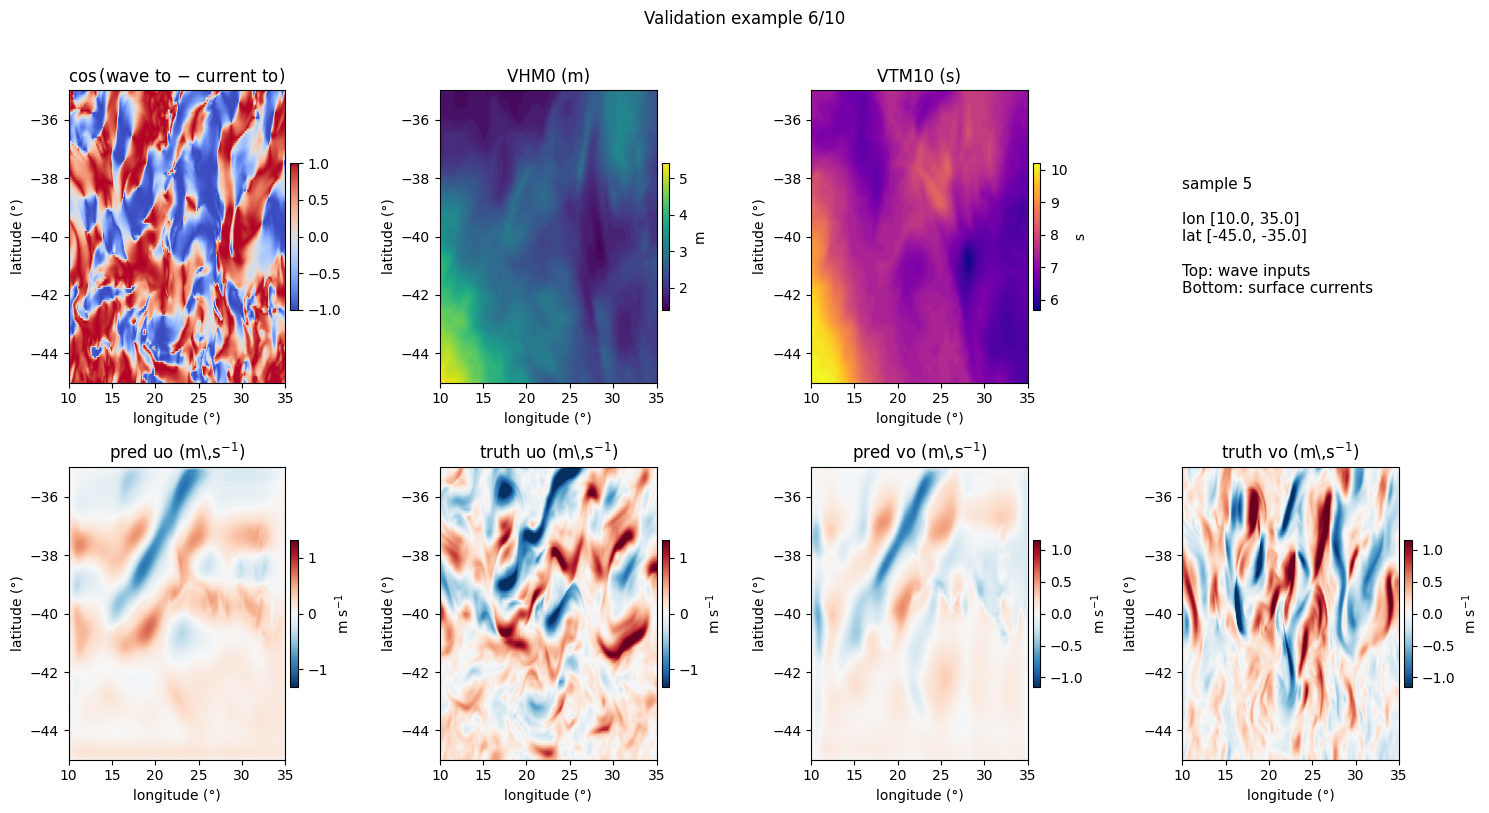

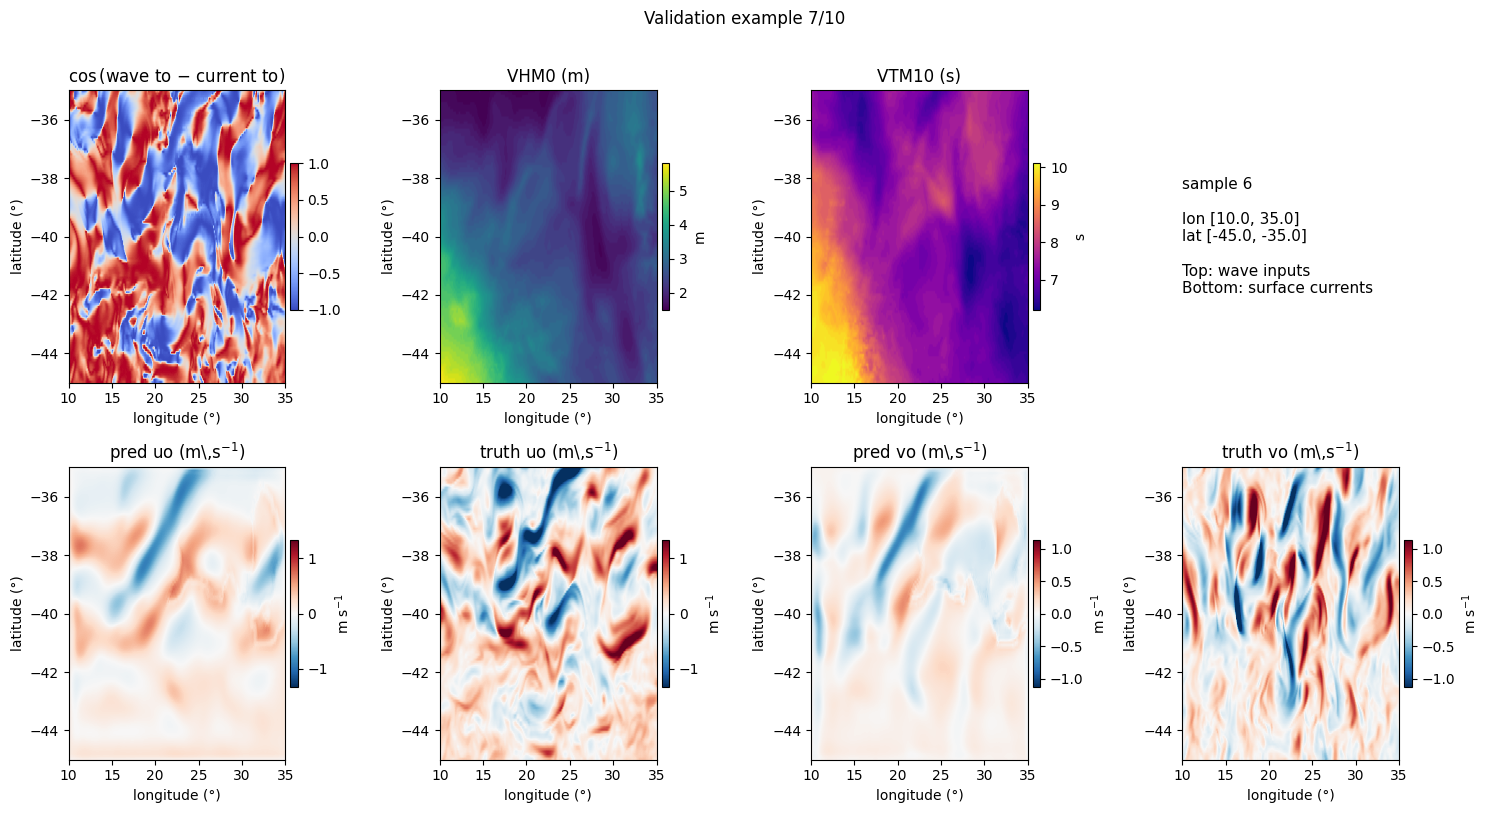

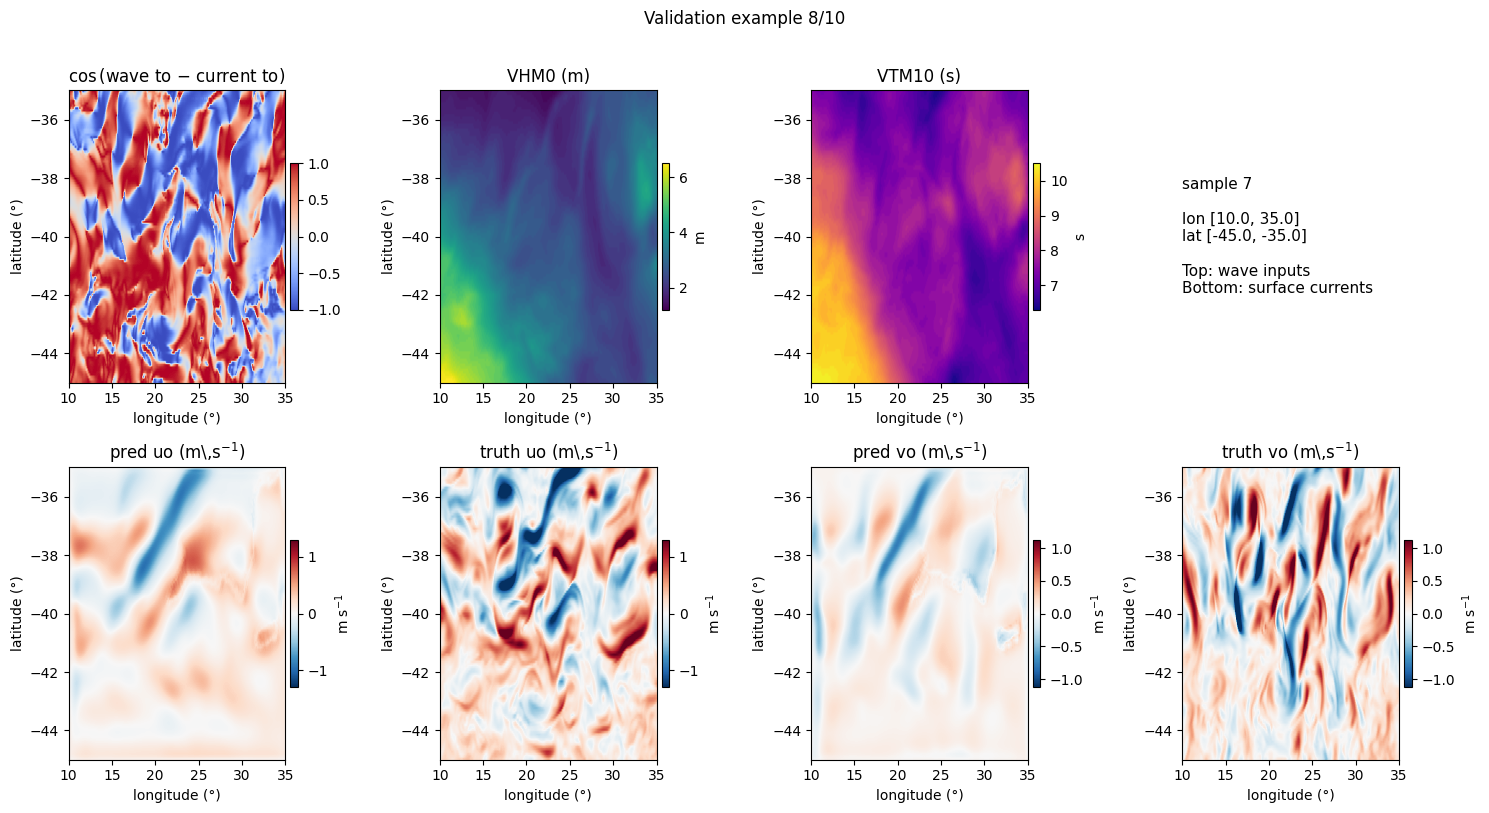

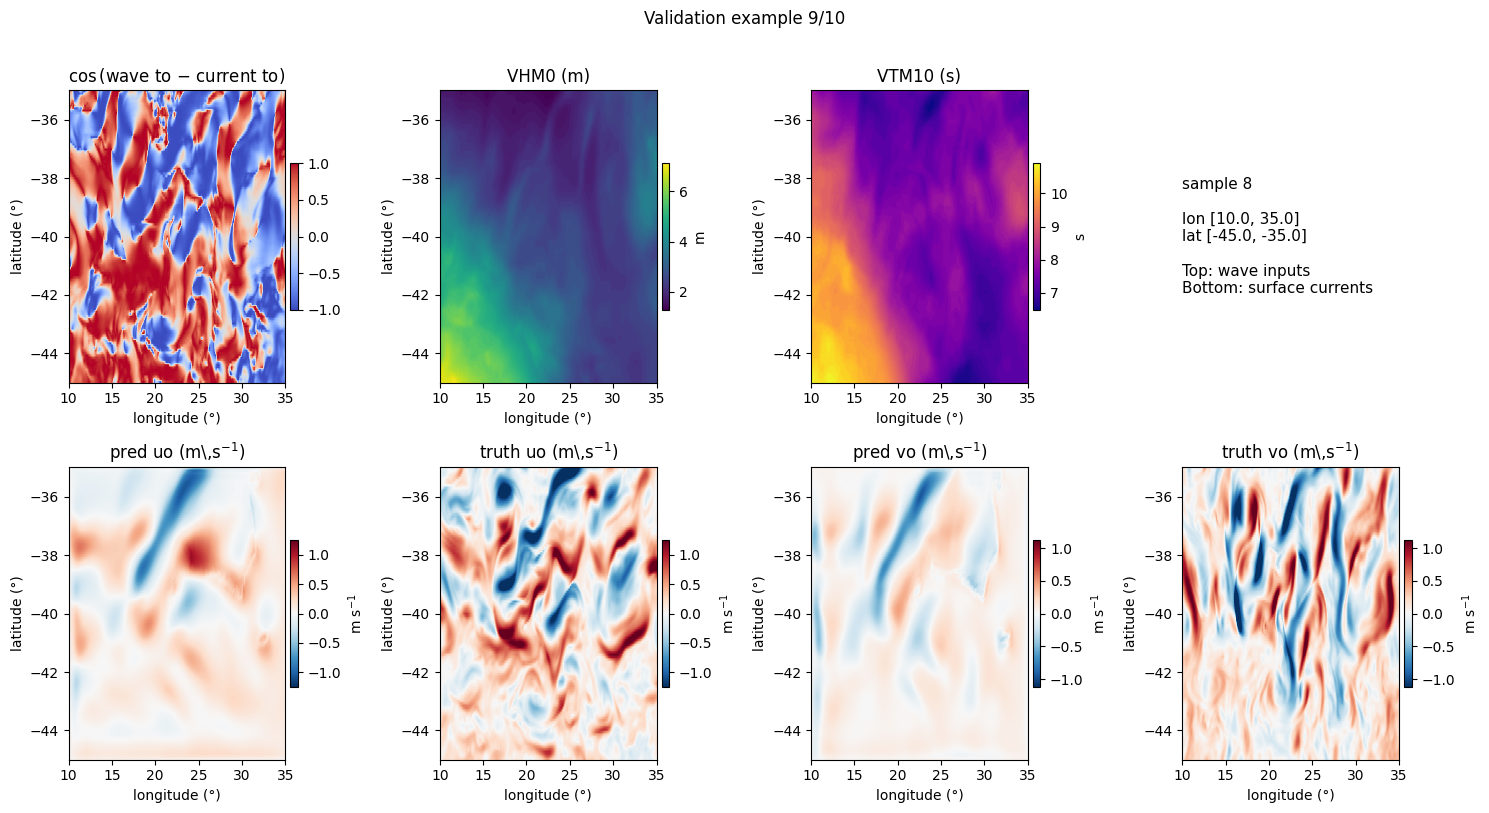

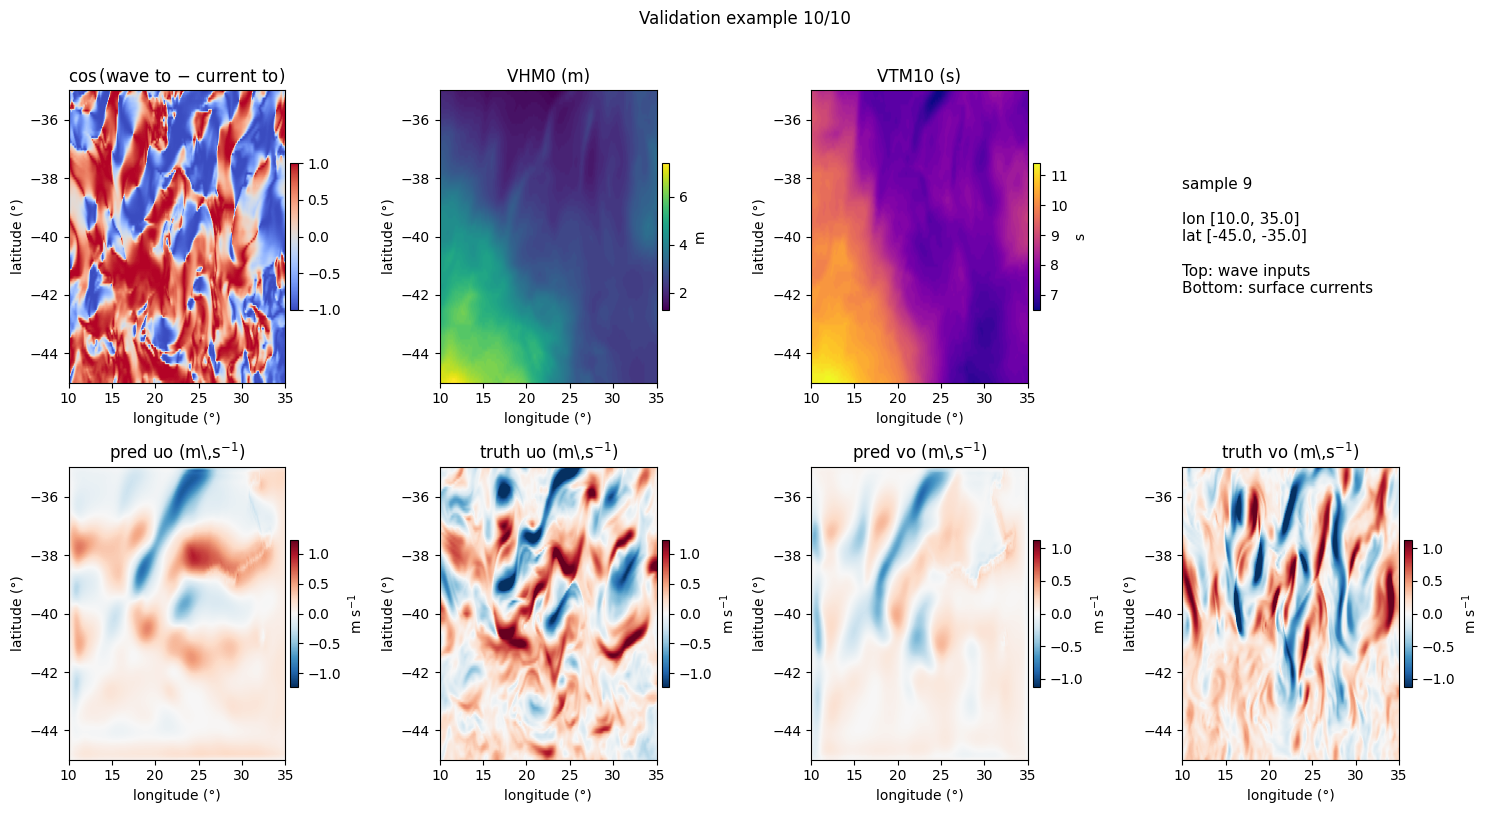

In [13]:
N_VAL_EXAMPLES = 10
plot_validation_examples(model, validation_dataset, device, n_examples=N_VAL_EXAMPLES)